# Gene expression clustering

**Goal:**
Cluster gene expression. Identify clusters of genes with similar profiles of activation or repression.

**Simple Procedure:**
1. Align peaks of gene expression
2. Then cluster.
3. Visualize expression of clusters to identify patterns of similar activation.
4. Visualize the chromatin of the activation, and repression timepoints.

**More complex**
1. Compute a distance matrix
2. For every pair of entries, compute a correlation score by sliding the vector down each timepoint. The value of the distance will be the translation the outcome the maximal correlation.

**Expected outcome:**
There may be some similar patterns among similarly activated genes. For example, a gene that rapidly activates may exhibit a stronger change in nucleosome shift than a gene that gradually turns on.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [892]:
from src.gene_clustering import GeneClustering

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'

gene_clustering = GeneClustering(outdir)

Selected 558 genes in the top 80% with quantile value greater than 1.19


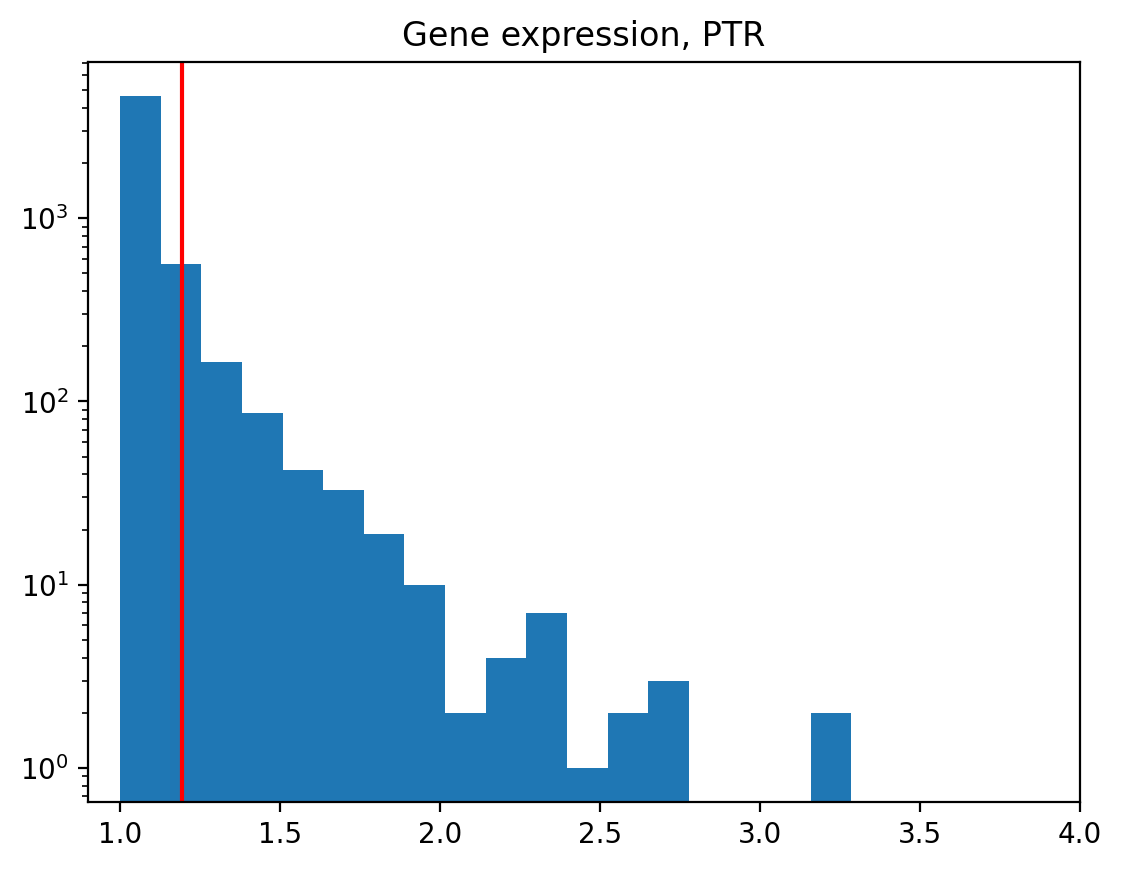

In [895]:
gene_clustering.set_threshold_ptr(0.9)

In [907]:
distance_matrix = gene_clustering.compute_distance_from_gene_expression()

0/558 - 00:00:00.272
100/558 - 00:00:22.178
200/558 - 00:00:39.193
300/558 - 00:00:51.934
400/558 - 00:01:00.446
500/558 - 00:01:04.848
00:01:05.501


In [1164]:
gene_clustering.cluster_expression(9)
gene_clustering.compute_medoids()

In [1173]:
medoid_indices = gene_clustering.kmedoids.medoid_indices_
gene_clustering.kmedoids.labels_[medoid_indices]

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [1559]:
gene_clustering.compute_alignments_and_interesting_points_per_cluster()

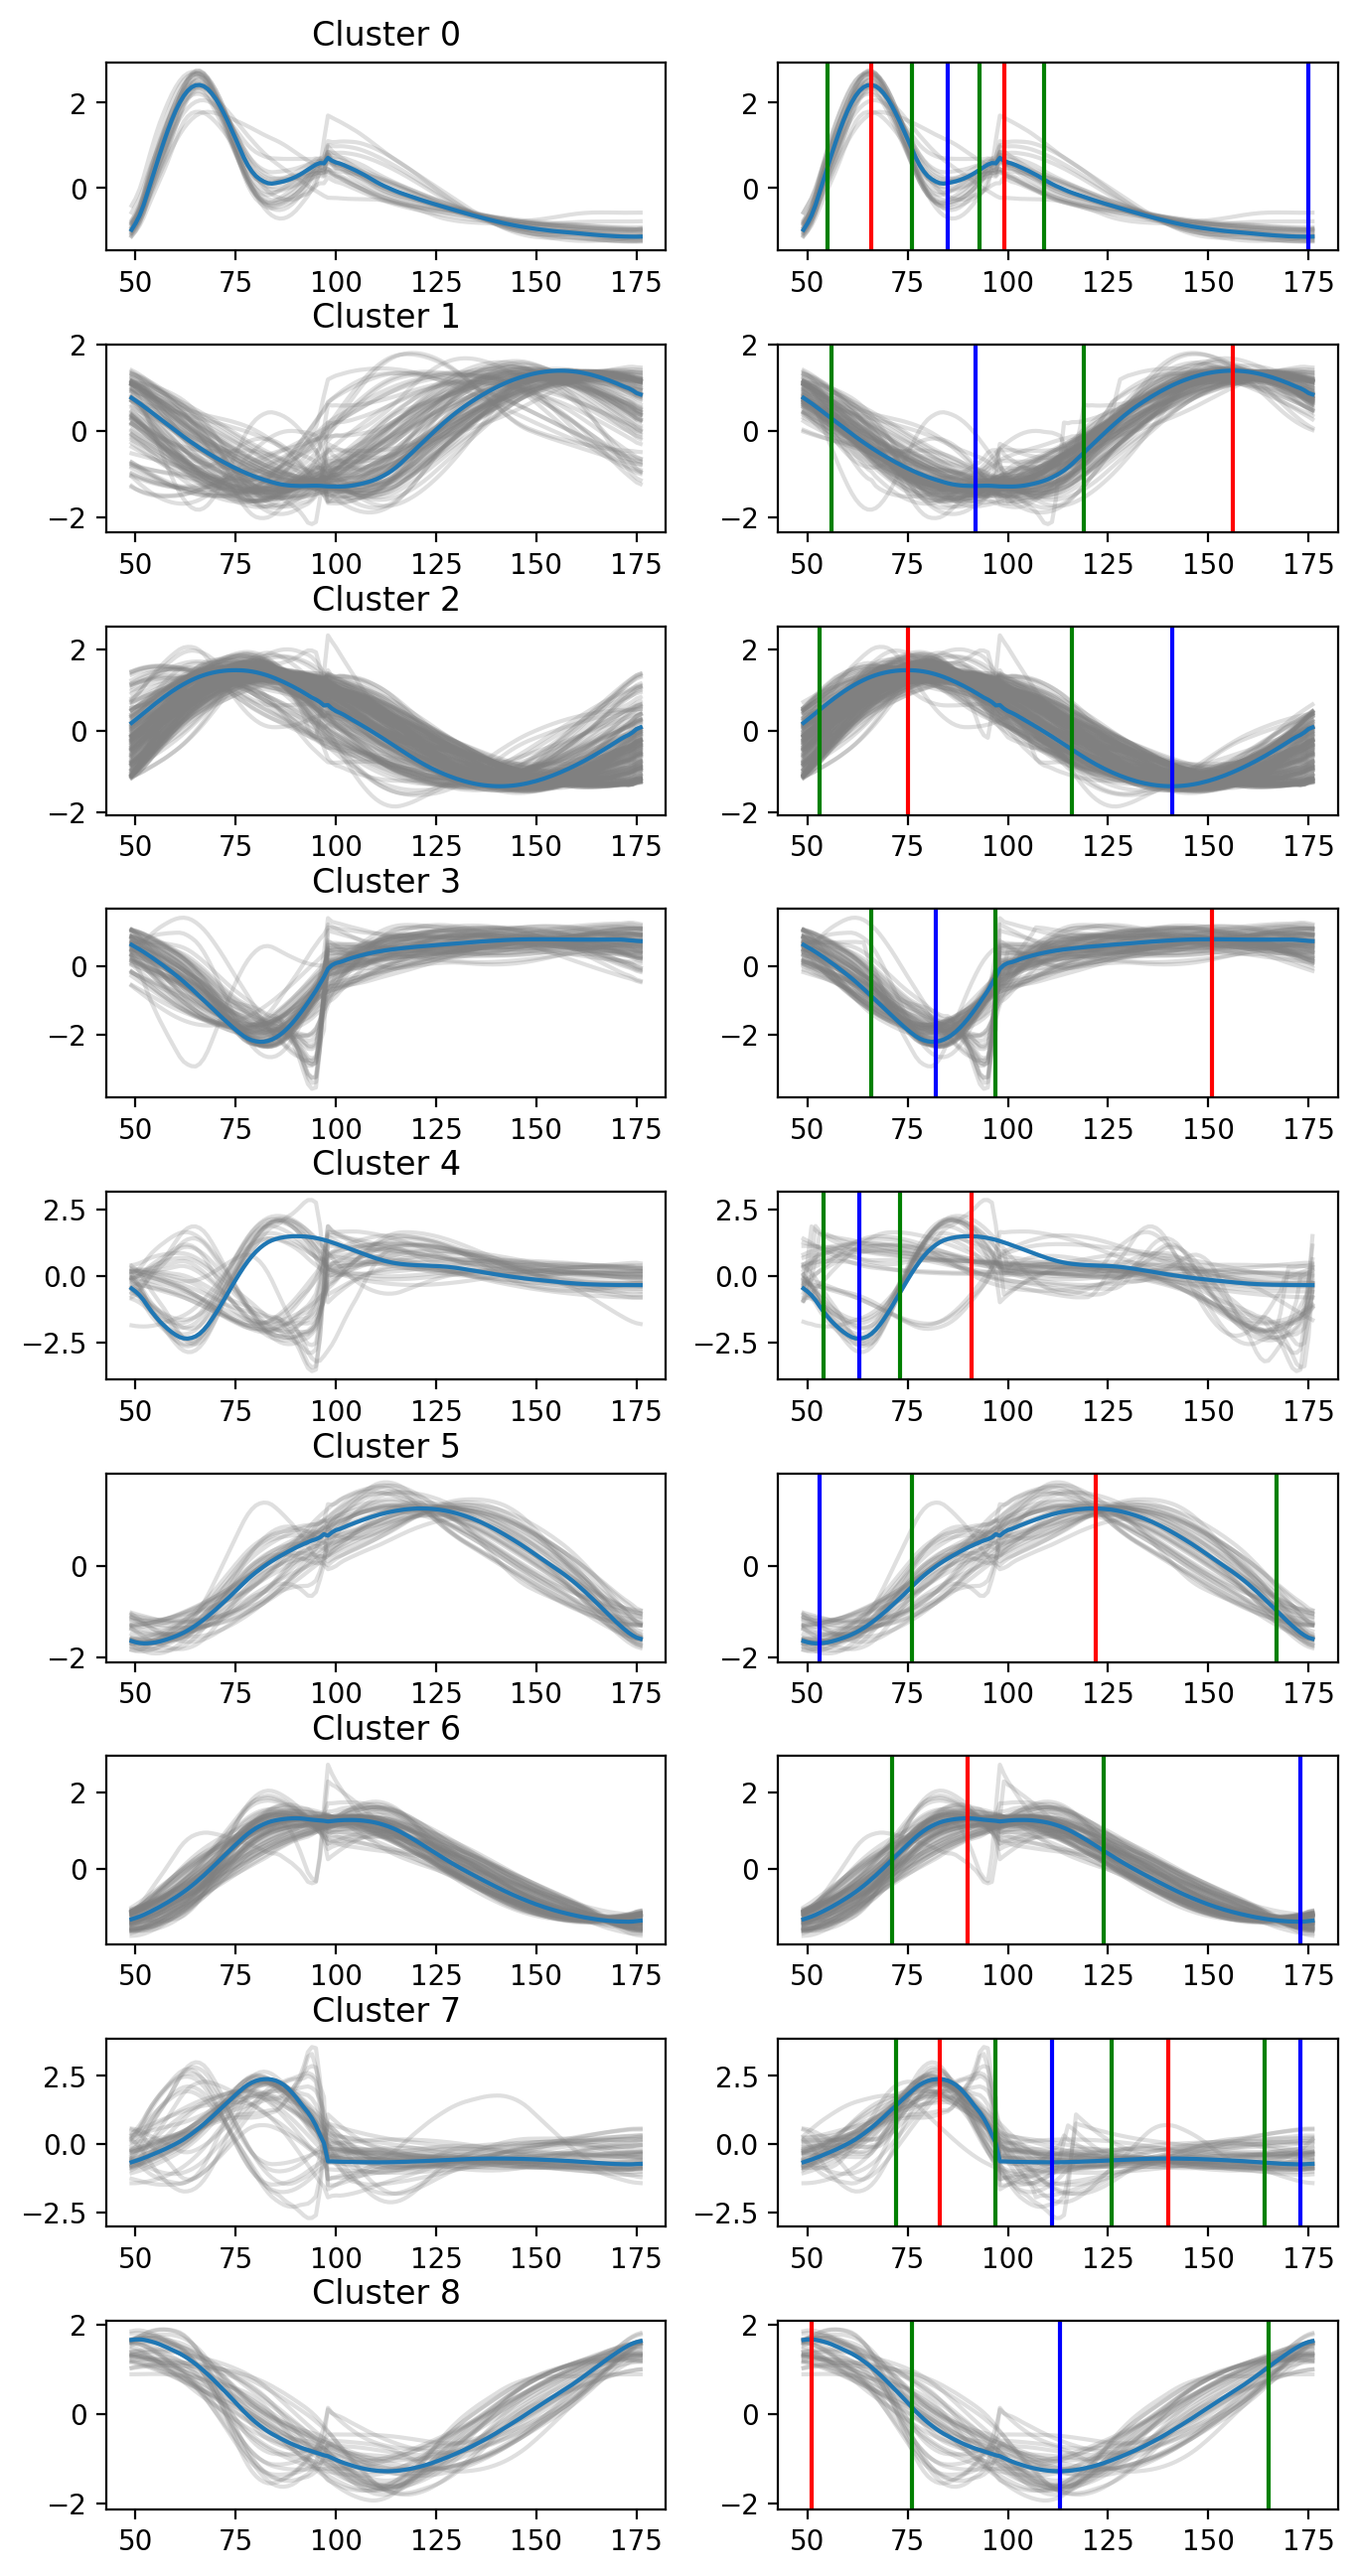

In [1560]:
gene_clustering.plot_aligned_clusters()

Text(0.5, 1.0, 'Gene expression sorted by cluster')

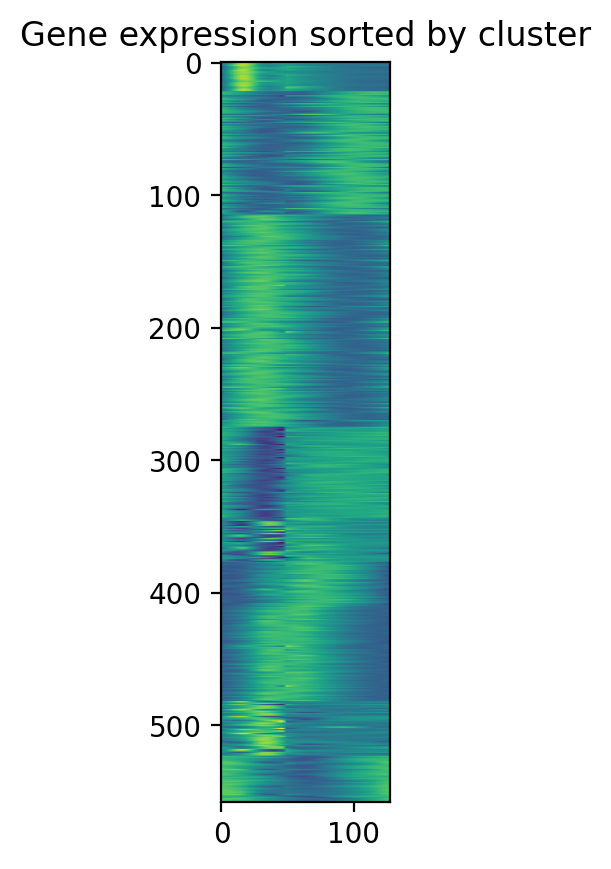

In [1432]:
gene_clustering.plot_clustered_heatmap()
plt.title("Gene expression sorted by cluster")

In [1561]:
for selected_cluster in range(gene_clustering.num_clusters):

    print(f"Cluster {selected_cluster}")
    chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/chromatin/'
    gene_clustering.load_chromatin_for_cluster(chromatin_dir, selected_cluster)
    gene_clustering.shift_cluster_chromatin_data()
    gene_clustering.plot_chromatin_in_cluster()
    save_path = f'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/clustering/chromatin_{selected_cluster}.png'
    plt.savefig(save_path, dpi=150)
    print(f"Saved to {save_path}")
    plt.cla()
    plt.clf()


Cluster 8
Shape of the loaded F: (178, 2093)
(178, 2093)
1/35 - 00:00:00.022
Saved to output/deconvolve_sharedg1_g0066_11x11_2024_08_13/clustering/chromatin_8.png


<Figure size 1300x600 with 0 Axes>